# CLIP API Tutorial

This notebook shows how to use **CLIP** (`openai/clip-vit-large-patch14`)
with the Hugging Face `transformers` library.

You will learn how to:
- Turn images and texts into vectors (embeddings).
- Compare an image with a text using cosine similarity.
- Classify images and texts without any training (zero-shot).

The examples use a few posts from the MVSA-Multiple dataset (tweets with an
image). The full sentiment analysis project is in `clip.example.ipynb`.

References:
- Radford et al., *Learning Transferable Visual Models From Natural Language
  Supervision*, 2021: https://arxiv.org/abs/2103.00020
- Hugging Face CLIP docs:
  https://huggingface.co/docs/transformers/model_doc/clip

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import pandas as pd
import torch

In [2]:
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

import clip_utils as cliputil

_LOG = logging.getLogger(__name__)

# Initialize notebook configuration and logging.
hdbg.init_logger(verbosity=logging.INFO)
hnotebook.config_notebook()
cliputil.init_loggers(_LOG)

INFO  > /usr/local/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-cf5962ef-964a-4444-a844-9734fb1be878.json


## What Is CLIP?

CLIP has two encoders:
- An **image encoder** (a Vision Transformer, ViT-L/14): it cuts an image
  into 14x14-pixel patches and reads them like words in a sentence.
- A **text encoder** (a Transformer): it reads a sentence of up to 77
  tokens.

Both encoders output a vector of the same size (768). OpenAI trained them
together on 400M image-caption pairs from the web, so that a matching image
and caption end up **close** to each other and non-matching pairs end up
**far apart** (contrastive learning).

```
image --> [image encoder] --> 768-d vector --+
                                             +--> cosine similarity
text  --> [text encoder]  --> 768-d vector --+
```

Because images and texts live in the same space, we can compare them
directly. In this project, CLIP is **frozen**: we only use it to turn posts
into vectors.

## Load the Model

- `CLIPModel` holds the two encoders.
- `CLIPProcessor` prepares the inputs: it resizes images and splits texts
  into tokens.

In [3]:
model, processor = cliputil.load_clip()
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params / 1e6:.0f}M")
print("Embedding size:", model.config.projection_dim)

WARNING Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Loaded openai/clip-vit-large-patch14 on cpu
Parameters: 428M
Embedding size: 768


## Pick a Few Posts

Show 2 posts per sentiment label from the test split.

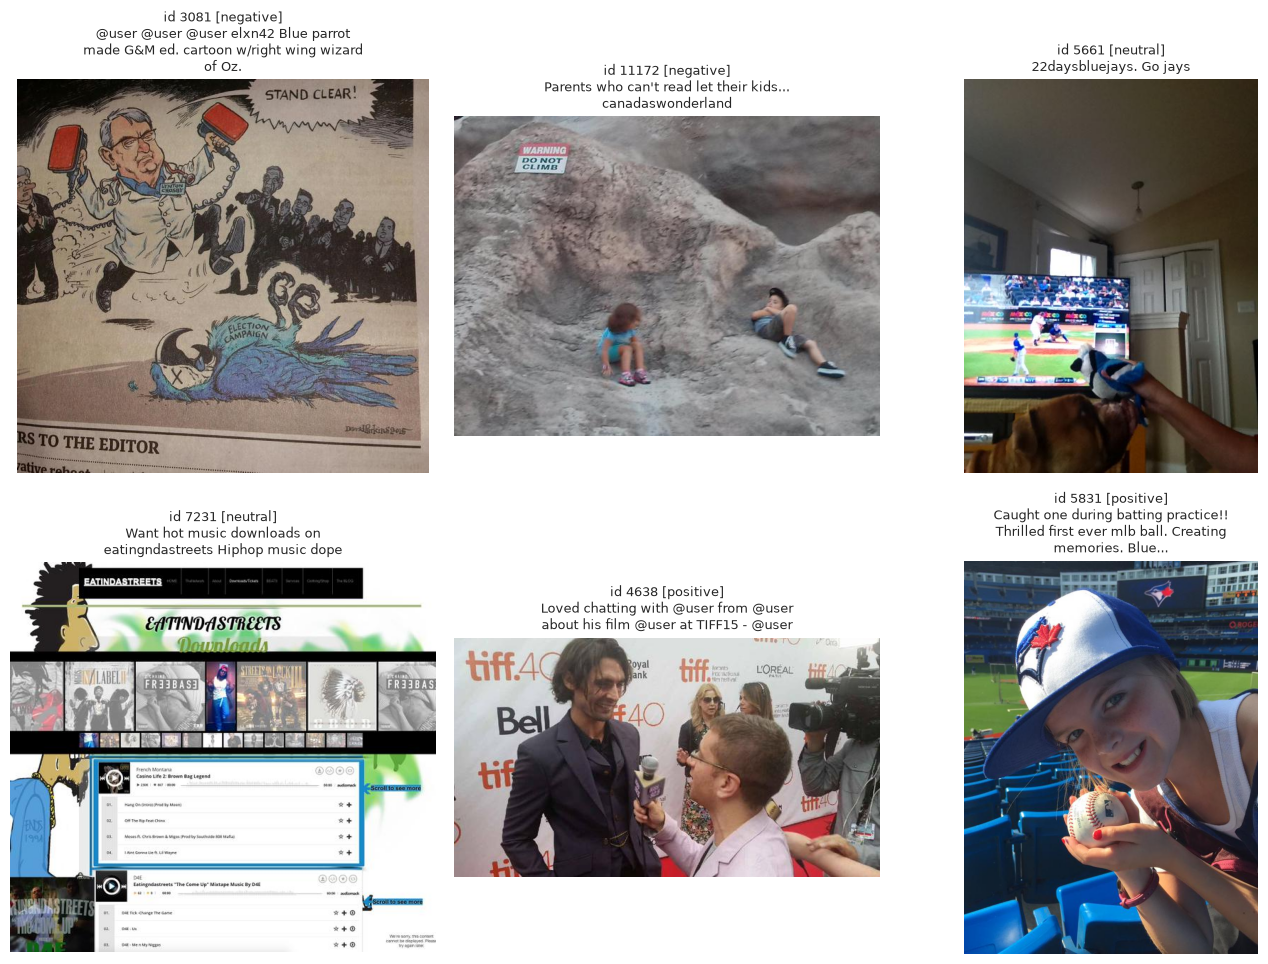

In [4]:
df = pd.read_csv("data/processed/labels.csv")
posts = cliputil.sample_posts(df, n_per_label=2, seed=0)
cliputil.show_posts(posts)

## Step 1: Preprocess the Inputs

**Images**: the processor resizes and crops each image to 224x224 pixels
and normalizes the colors. With 14x14 patches, each image becomes
16 x 16 = 256 patches.

In [5]:
images = cliputil.load_images(posts["image_path"].tolist())
image_inputs = processor(images=images, return_tensors="pt")
# Shape: (images, color channels, height, width).
print(image_inputs["pixel_values"].shape)

torch.Size([6, 3, 224, 224])


**Texts**: the processor splits each text into tokens and pads them to the
same length. The text encoder accepts at most **77 tokens**, so longer texts
must be cut (`truncation=True`).

In [6]:
text_inputs = processor(
    text=posts["text"].tolist(),
    padding=True,
    truncation=True,
    max_length=cliputil.MAX_TEXT_TOKENS,
    return_tensors="pt",
)
# Shape: (texts, tokens).
print(text_inputs["input_ids"].shape)
print(posts["text"].iloc[0])
print(processor.tokenizer.convert_ids_to_tokens(text_inputs["input_ids"][0]))

torch.Size([6, 28])
@user @user @user elxn42 Blue parrot made G&M ed. cartoon w/right wing wizard of Oz.
['<|startoftext|>', '@</w>', 'user</w>', '@</w>', 'user</w>', '@</w>', 'user</w>', 'elxn</w>', '4</w>', '2</w>', 'blue</w>', 'parrot</w>', 'made</w>', 'g</w>', '&</w>', 'm</w>', 'ed</w>', '.</w>', 'cartoon</w>', 'w</w>', '/</w>', 'right</w>', 'wing</w>', 'wizard</w>', 'of</w>', 'oz</w>', '.</w>', '<|endoftext|>']


Tweets are short, so the 77-token limit is not a problem for this dataset.

In [7]:
n_long = cliputil.count_truncated_texts(df["text"].tolist(), processor)
print(f"Tweets longer than 77 tokens: {n_long} / {len(df)}")

Tweets longer than 77 tokens: 0 / 17025


## Step 2: Get the Embeddings

- `get_image_features()` and `get_text_features()` return one 768-d vector
  per input.
- We then scale each vector to length 1 (L2 normalization). After this, the
  dot product of two vectors is their **cosine similarity**, a number
  between -1 and 1.

In [8]:
dim = model.config.projection_dim
with torch.inference_mode():
    image_emb = cliputil.as_embedding(model.get_image_features(**image_inputs), dim)
    text_emb = cliputil.as_embedding(model.get_text_features(**text_inputs), dim)
print("Shapes:", tuple(image_emb.shape), tuple(text_emb.shape))
print("Vector lengths before normalization:", image_emb.norm(dim=-1)[:3])

image_emb = image_emb / image_emb.norm(dim=-1, keepdim=True)
text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
print("Vector lengths after normalization:", image_emb.norm(dim=-1)[:3])

Shapes: (6, 768) (6, 768)
Vector lengths before normalization: tensor([16.0391, 17.9605, 17.5995])
Vector lengths after normalization: tensor([1.0000, 1.0000, 1.0000])


`cliputil.embed_images()` and `cliputil.embed_texts()` run these steps in
batches for a whole dataset.

## Step 3: Compare Images and Texts

Each cell is the cosine similarity between the image of one post (row) and
the text of another post (column). The diagonal pairs each image with its
own tweet.

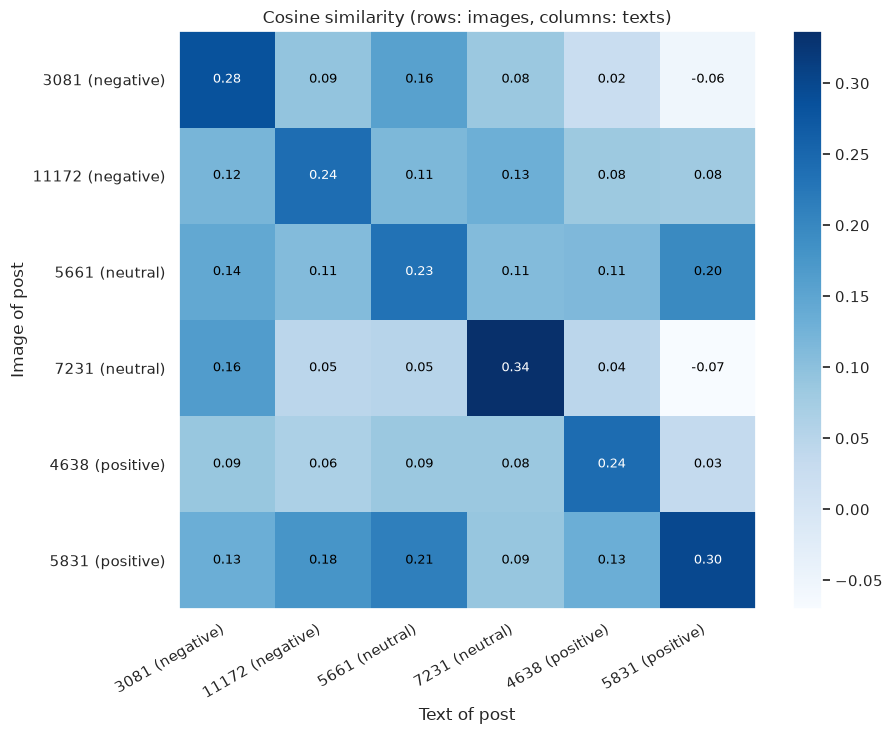

In [9]:
sim = (image_emb @ text_emb.T).numpy()
names = [f"{i} ({lab})" for i, lab in zip(posts["id"], posts["label"])]
cliputil.plot_similarity(sim, row_labels=names, col_labels=names)

In this sample, each image is most similar to its own tweet (the diagonal).
The values are still low (around 0.2-0.35) because tweets are not image
captions: they often talk about something the image does not show.

## Step 4: Zero-Shot Classification

CLIP can classify without training:
1. Write one sentence (prompt) per class.
2. Embed the prompts with the text encoder.
3. Pick the class whose prompt is most similar to the input.

The probabilities come from a softmax over the similarities, scaled by a
temperature that CLIP learned during training (`logit_scale`).

In [10]:
image_prompts = [
    "a photo with a negative mood",
    "a photo with a neutral mood",
    "a photo with a positive mood",
]
probs = cliputil.zero_shot_probs(image_emb.numpy(), image_prompts, model, processor)
cliputil.zero_shot_table(posts, probs)

,negative,neutral,positive,predicted,true
id,,,,,
3081,0.70,0.09,0.22,negative,negative
11172,0.69,0.19,0.12,negative,negative
5661,0.15,0.14,0.71,positive,neutral
7231,0.46,0.02,0.52,positive,neutral
4638,0.04,0.02,0.94,positive,positive
5831,0.07,0.09,0.84,positive,positive


The same works for texts: compare each tweet with sentences describing a
sentiment.

In [11]:
text_prompts = [
    "a negative message",
    "a neutral message",
    "a positive message",
]
probs = cliputil.zero_shot_probs(text_emb.numpy(), text_prompts, model, processor)
cliputil.zero_shot_table(posts, probs)

,negative,neutral,positive,predicted,true
id,,,,,
3081,0.08,0.32,0.60,positive,negative
11172,0.16,0.16,0.68,positive,negative
5661,0.01,0.23,0.77,positive,neutral
7231,0.03,0.49,0.48,neutral,neutral
4638,0.35,0.18,0.47,positive,positive
5831,0.00,0.03,0.96,positive,positive


The wording of the prompts matters. Change the image prompts and compare the
predictions with the first table.

In [12]:
image_prompts_v2 = ["a sad photo", "an ordinary photo", "a happy photo"]
probs = cliputil.zero_shot_probs(image_emb.numpy(), image_prompts_v2, model, processor)
cliputil.zero_shot_table(posts, probs)

,negative,neutral,positive,predicted,true
id,,,,,
3081,0.77,0.11,0.11,negative,negative
11172,0.36,0.49,0.15,neutral,negative
5661,0.45,0.15,0.40,negative,neutral
7231,0.76,0.12,0.12,negative,neutral
4638,0.15,0.05,0.79,positive,positive
5831,0.22,0.13,0.64,positive,positive


Zero-shot gets some posts right with no training at all, but it is far from
perfect, and changing a few words in the prompts changes several
predictions. Sarcasm is also hard: a negative tweet can use positive words.

## Summary

- `CLIPProcessor` prepares images (224x224) and texts (up to 77 tokens).
- `get_image_features()` and `get_text_features()` map both into the same
  768-d space; after L2 normalization, a dot product is a cosine similarity.
- Zero-shot classification needs only one prompt per class, but its results
  depend on the prompt wording.

In `clip.example.ipynb`, we measure zero-shot accuracy on the full test set
and train our own classifier on top of the frozen CLIP embeddings.